In [1]:
import pandas as pd 
import numpy as np
import torch
from collections import OrderedDict
from typing import Dict, List, Tuple

In [2]:
# =============================================================================
# Konfigurasi path dataset
# =============================================================================
BASE_DIR = r"C:\Users\s2\Documents\Federated\dataset"

PATHS = {
    "drebin": f"{BASE_DIR}/drebin-215-dataset-5560malware-9476-benign.csv",
    "kronodroid": f"{BASE_DIR}/kronodroid.csv",
    "malgenome": f"{BASE_DIR}/malgenome.csv",
    "tuandromd": f"{BASE_DIR}/TUANDROMD 2.csv",
}


# %%
# =============================================================================
# Fungsi bantu
# =============================================================================
def load_raw(path: str) -> pd.DataFrame:
    """Baca CSV dan buang kolom index bawaan ('Unnamed: 0') kalau ada."""
    data = pd.read_csv(path)
    if "Unnamed: 0" in data.columns:
        data = data.drop(columns=["Unnamed: 0"])
    return data


def encode_label(data: pd.DataFrame, label_col: str, mapping: Dict) -> pd.DataFrame:
    """Encode kolom label sesuai mapping, mis. {'B': 0, 'S': 1}."""
    data = data.copy()
    data[label_col] = data[label_col].replace(mapping)
    return data


def to_numeric_features(data: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Paksa semua kolom selain label jadi numerik; nilai gagal -> NaN."""
    data = data.copy()
    feature_columns = [c for c in data.columns if c != label_col]
    data[feature_columns] = data[feature_columns].apply(pd.to_numeric, errors="coerce")
    return data


def report(name: str, X: np.ndarray, y: np.ndarray) -> None:
    print(f"[{name}]")
    print("  Ukuran X       :", X.shape)
    print("  Ukuran y       :", y.shape)
    print("  Distribusi kelas:", np.bincount(y))
    print()


def split_features_labels(
    data: pd.DataFrame, label_col: str
) -> Tuple[np.ndarray, np.ndarray]:
    X = data.drop(columns=[label_col]).values.astype(np.float32)
    y = data[label_col].astype(int).values
    return X, y


In [3]:
from dataset import split_and_prepare_data
# =============================================================================
# 1. Dataset Drebin
# =============================================================================
LABEL_COLUMN = "class"  # sesuaikan dengan nama kolom label sebenarnya di file Drebin
SPECIAL_COLUMN = "TelephonyManager.getSimCountryIso"
 
data = load_raw(PATHS["drebin"])
 
if SPECIAL_COLUMN in data.columns:
    data[SPECIAL_COLUMN] = data[SPECIAL_COLUMN].replace("?", np.nan)
    data[SPECIAL_COLUMN] = pd.to_numeric(data[SPECIAL_COLUMN], errors="coerce")
 
if LABEL_COLUMN not in data.columns:
    raise KeyError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan. Kolom tersedia: {list(data.columns)}")
 
data = encode_label(data, LABEL_COLUMN, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COLUMN)
data = data.dropna().reset_index(drop=True)
 
X_drebin, y_drebin = split_features_labels(data, LABEL_COLUMN)
N_CLASSES = len(np.unique(y_drebin))
N_FEATURES = X_drebin.shape[1]
 
report("Drebin", X_drebin, y_drebin)
print("Jumlah kelas:", N_CLASSES)
 
drebin_split = split_and_prepare_data(X_drebin, y_drebin)
 
 
# %%
# =============================================================================
# 2. Dataset KronoDroid
# =============================================================================
LABEL_COL_KRONO = "Malware"
 
data = load_raw(PATHS["kronodroid"])
print("Ukuran data awal:", data.shape)
print("\nMissing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("\nNilai unik Malware:", data[LABEL_COL_KRONO].unique())
print("Distribusi kelas Malware:\n", data[LABEL_COL_KRONO].value_counts())
 
data = to_numeric_features(data, LABEL_COL_KRONO)
data = data.dropna().reset_index(drop=True)
 
X_krono, y_krono = split_features_labels(data, LABEL_COL_KRONO)
target_names_krono = ["goodware", "malware"]
 
report("KronoDroid", X_krono, y_krono)
print("Jumlah fitur:", X_krono.shape[1])
 
krono_split = split_and_prepare_data(X_krono, y_krono)
 
 
# %%
# =============================================================================
# 3. Dataset MalGenome
# =============================================================================
LABEL_COL_MALGENOME = "class"
 
data = load_raw(PATHS["malgenome"])
print("Missing value per kolom:\n", data.isna().sum())
 
data = encode_label(data, LABEL_COL_MALGENOME, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COL_MALGENOME)
data = data.dropna().reset_index(drop=True)
 
X_malgenome, y_malgenome = split_features_labels(data, LABEL_COL_MALGENOME)
target_names_malgenome = ["benign", "malware"]
 
report("MalGenome", X_malgenome, y_malgenome)
 
malgenome_split = split_and_prepare_data(X_malgenome, y_malgenome)

# =============================================================================
# 4. Dataset TUANDROMD
# =============================================================================
LABEL_COL_TUANDROMD = "Label"
 
data = load_raw(PATHS["tuandromd"])
print("Missing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("Nilai unik Label:", data[LABEL_COL_TUANDROMD].unique())
 
data = encode_label(data, LABEL_COL_TUANDROMD, {"goodware": 0, "malware": 1})
data = to_numeric_features(data, LABEL_COL_TUANDROMD)
data = data.dropna().reset_index(drop=True)
 
X_tuandromd, y_tuandromd = split_features_labels(data, LABEL_COL_TUANDROMD)
target_names_tuandromd = ["goodware", "malware"]
 
report("TUANDROMD", X_tuandromd, y_tuandromd)
 
tuandromd_split = split_and_prepare_data(X_tuandromd, y_tuandromd)

C:\Users\s2\AppData\Local\Temp\ipykernel_15648\1764348774.py:20: DtypeWarning: Columns (92: TelephonyManager.getSimCountryIso) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


[Drebin]
  Ukuran X       : (15031, 215)
  Ukuran y       : (15031,)
  Distribusi kelas: [9476 5555]

Jumlah kelas: 2
Train: torch.Size([10521, 215]) | Val: torch.Size([2255, 215]) | Test: torch.Size([2255, 215])
Ukuran data awal: (78137, 463)

Missing value sebelum drop: 0
Missing value setelah drop: 0

Nilai unik Malware: [1 0]
Distribusi kelas Malware:
 Malware
1    41382
0    36755
Name: count, dtype: int64
[KronoDroid]
  Ukuran X       : (78137, 462)
  Ukuran y       : (78137,)
  Distribusi kelas: [36755 41382]

Jumlah fitur: 462
Train: torch.Size([54695, 462]) | Val: torch.Size([11721, 462]) | Test: torch.Size([11721, 462])
Missing value per kolom:
 transact                                 0
bindService                              0
onServiceConnected                       0
ServiceConnection                        0
android.os.Binder                        0
                                        ..
GLOBAL_SEARCH                            0
GET_PACKAGE_SIZE                   

In [4]:
# Ringkasan semua split
# =============================================================================
all_splits = {
    "drebin": drebin_split,
    "kronodroid": krono_split,
    "malgenome": malgenome_split,
    "tuandromd": tuandromd_split,
}
 
for name, split in all_splits.items():
    print(f"\n[{name}]")
    print("  X_train:", split["X_train_t"].shape)
    print("  X_val  :", split["X_val_t"].shape)
    print("  X_test :", split["X_test_t"].shape)


[drebin]
  X_train: torch.Size([10521, 215])
  X_val  : torch.Size([2255, 215])
  X_test : torch.Size([2255, 215])

[kronodroid]
  X_train: torch.Size([54695, 462])
  X_val  : torch.Size([11721, 462])
  X_test : torch.Size([11721, 462])

[malgenome]
  X_train: torch.Size([2659, 215])
  X_val  : torch.Size([570, 215])
  X_test : torch.Size([570, 215])

[tuandromd]
  X_train: torch.Size([3124, 241])
  X_val  : torch.Size([670, 241])
  X_test : torch.Size([670, 241])


In [5]:
# %% [Cell 2] -- siapkan fed_data (seperti sebelumnya)
from fl_running7 import (
    run_federated, print_theta_report, theta_report_to_rows, approx_theta_gap,
    print_theta_before_after_report,   # NEW
)
import pandas as pd
import matplotlib.pyplot as plt

n_features_map = {
    "drebin":     X_drebin.shape[1],
    "kronodroid": X_krono.shape[1],
    "malgenome":  X_malgenome.shape[1],
    "tuandromd":  X_tuandromd.shape[1],
}

fed_data = {}
for name, split in all_splits.items():
    fed_data[name] = {
        "X_train": split["X_train_t"], "y_train": split["y_train_t"],
        "X_val":   split["X_val_t"],   "y_val":   split["y_val_t"],
        "X_test":  split["X_test_t"],  "y_test":  split["y_test_t"],
        "n_features": n_features_map[name],
    }

for name, c in fed_data.items():
    print(name, "n_features =", c["n_features"], "train", tuple(c["X_train"].shape))

2026-09-25 16:45:31,413	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


drebin n_features = 215 train (10521, 215)
kronodroid n_features = 462 train (54695, 462)
malgenome n_features = 215 train (2659, 215)
tuandromd n_features = 241 train (3124, 241)


In [6]:
# %% [Cell 3] -- jalankan training (SEKALI SAJA)
COMMON = dict(
    common_dim=128,
    n_classes=2,
    num_rounds=20,
    local_epochs=2,
)

history = run_federated(fed_data, name="FedPer", **COMMON)

INFO :      Starting Flower ServerApp, config: num_rounds=20, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.1464554090052843, {'accuracy': 0.9435901919596181, 'precision': 0.9723671512841752, 'recall': 0.9161411069604641, 'f1': 0.9391566318177362}, 12.225420800037682)
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)


[FedPer] round 01 | loss=0.1465 acc=0.9436 f1=0.9392 | comm=0.315MB (cum 0.315MB)


INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.11985710868611932, {'accuracy': 0.9627527920405992, 'precision': 0.9862359050049566, 'recall': 0.9400989085983495, 'f1': 0.9606677307882258}, 17.66508150001755)
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)


[FedPer] round 02 | loss=0.1199 acc=0.9628 f1=0.9607 | comm=0.315MB (cum 0.631MB)


INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (3, 0.12315165484324098, {'accuracy': 0.9662019444695279, 'precision': 0.9857367493874519, 'recall': 0.946231379519441, 'f1': 0.963966069950688}, 23.069168100017123)
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)


...

[FedPer] round 19 | loss=0.3500 acc=0.9676 f1=0.9642 | comm=0.315MB (cum 5.993MB)


INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 20]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (20, 0.41569178737699986, {'accuracy': 0.9681172652708653, 'precision': 0.9722481623131961, 'recall': 0.9594615355405897, 'f1': 0.9643607802701205}, 115.73066040000413)
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)


[FedPer] round 20 | loss=0.4157 acc=0.9681 f1=0.9644 | comm=0.315MB (cum 6.309MB)


INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 116.74s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.2459566177057774
INFO :      		round 2: 0.2477677331673813
INFO :      		round 3: 0.2583481395898574
INFO :      		round 4: 0.3027681106307335
INFO :      		round 5: 0.2751455084140927
INFO :      		round 6: 0.32648899659212033
INFO :      		round 7: 0.3840244193581986
INFO :      		round 8: 0.34161412996344914
INFO :      		round 9: 0.2790868844785558
INFO :      		round 10: 0.28603483955700965
INFO :      		round 11: 0.29524701030466144
INFO :      		round 12: 0.3552824395558365
INFO :      		round 13: 0.3341044439674404
INFO :      		round 14: 0.2760723537427221
INFO :      		round 15: 0.42584118581871
INFO :      		round 16: 0.4055621578137369
INFO :      		round 17: 0.4998424731866476
INFO :      		round 18: 0.5514942450363312
INFO :      		round 19: 0.4603535589778842

[FedPer] BANDWIDTH | theta=0.039MB up=3.15MB down=3.15MB total=6.31MB (~0.32MB/ronde)


In [7]:
# %%
# Laporan teks: theta SEBELUM vs SESUDAH training lokal, per client per ronde
print_theta_before_after_report(history["theta_log_before"], history["theta_log"])


=== THETA SEBELUM vs SESUDAH TRAINING LOKAL (per client, per round) ===

[malgenome]
  round 01 | norm_recv=nan -> norm_after=6.3612 (Δ=6.3612)
  round 02 | norm_recv=nan -> norm_after=6.5617 (Δ=6.5617)
  round 03 | norm_recv=nan -> norm_after=6.7724 (Δ=6.7724)
  round 04 | norm_recv=nan -> norm_after=6.9564 (Δ=6.9564)
  round 05 | norm_recv=nan -> norm_after=7.1938 (Δ=7.1938)
  round 06 | norm_recv=nan -> norm_after=7.4135 (Δ=7.4135)
  round 07 | norm_recv=nan -> norm_after=7.6272 (Δ=7.6272)
  round 08 | norm_recv=nan -> norm_after=7.8190 (Δ=7.8190)
  round 09 | norm_recv=nan -> norm_after=8.0700 (Δ=8.0700)
  round 10 | norm_recv=nan -> norm_after=8.2481 (Δ=8.2481)
  round 11 | norm_recv=nan -> norm_after=8.3521 (Δ=8.3521)
  round 12 | norm_recv=nan -> norm_after=8.6163 (Δ=8.6163)
  round 13 | norm_recv=nan -> norm_after=8.7715 (Δ=8.7715)
  round 14 | norm_recv=nan -> norm_after=8.9526 (Δ=8.9526)
  round 15 | norm_recv=nan -> norm_after=9.1023 (Δ=9.1023)
  round 16 | norm_recv=nan ->

In [8]:
print_theta_report(history["theta_log"], history["global_theta_per_round"])


=== LAPORAN THETA PER CLIENT ===

[malgenome]
  round 01 | n_params=10336 mean=0.01176 std=0.06145 norm=6.3612 min=-0.1600 max=0.1694
  round 02 | n_params=10336 mean=0.01415 std=0.06297 norm=6.5617 min=-0.1816 max=0.1842
  round 03 | n_params=10336 mean=0.01436 std=0.06505 norm=6.7724 min=-0.1771 max=0.1961
  round 04 | n_params=10336 mean=0.01428 std=0.06692 norm=6.9564 min=-0.1825 max=0.2126
  round 05 | n_params=10336 mean=0.01446 std=0.06927 norm=7.1938 min=-0.1944 max=0.2277
  round 06 | n_params=10336 mean=0.01600 std=0.07114 norm=7.4135 min=-0.2079 max=0.2386
  round 07 | n_params=10336 mean=0.01569 std=0.07336 norm=7.6272 min=-0.2098 max=0.2415
  round 08 | n_params=10336 mean=0.01627 std=0.07517 norm=7.8190 min=-0.2162 max=0.2507
  round 09 | n_params=10336 mean=0.01657 std=0.07763 norm=8.0700 min=-0.2236 max=0.2791
  round 10 | n_params=10336 mean=0.01744 std=0.07923 norm=8.2481 min=-0.2248 max=0.2753
  round 11 | n_params=10336 mean=0.01672 std=0.08043 norm=8.3521 min=-0.2


=== LAPORAN THETA PER CLIENT ===

[malgenome]
  round 01 | n_params=10336 mean=0.01176 std=0.06145 norm=6.3612 min=-0.1600 max=0.1694
  round 02 | n_params=10336 mean=0.01415 std=0.06297 norm=6.5617 min=-0.1816 max=0.1842
  round 03 | n_params=10336 mean=0.01436 std=0.06505 norm=6.7724 min=-0.1771 max=0.1961
  round 04 | n_params=10336 mean=0.01428 std=0.06692 norm=6.9564 min=-0.1825 max=0.2126
  round 05 | n_params=10336 mean=0.01446 std=0.06927 norm=7.1938 min=-0.1944 max=0.2277
  round 06 | n_params=10336 mean=0.01600 std=0.07114 norm=7.4135 min=-0.2079 max=0.2386
  round 07 | n_params=10336 mean=0.01569 std=0.07336 norm=7.6272 min=-0.2098 max=0.2415
  round 08 | n_params=10336 mean=0.01627 std=0.07517 norm=7.8190 min=-0.2162 max=0.2507
  round 09 | n_params=10336 mean=0.01657 std=0.07763 norm=8.0700 min=-0.2236 max=0.2791
  round 10 | n_params=10336 mean=0.01744 std=0.07923 norm=8.2481 min=-0.2248 max=0.2753
  round 11 | n_params=10336 mean=0.01672 std=0.08043 norm=8.3521 min=-0.2

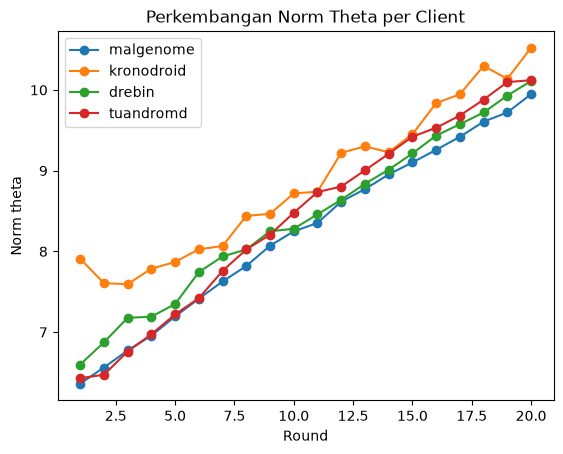

In [9]:

# %%
# Laporan teks: statistik theta tiap client tiap ronde
print_theta_report(history["theta_log"], history["global_theta_per_round"])

# %%
# Tabel (lebih enak dibaca di notebook)
df_theta = pd.DataFrame(theta_report_to_rows(history["theta_log"]))
df_theta

# %%
# Plot norm theta per client per ronde
for cname in df_theta["client"].unique():
    sub = df_theta[df_theta["client"] == cname]
    plt.plot(sub["round"], sub["norm"], marker="o", label=cname)

plt.xlabel("Round")
plt.ylabel("Norm theta")
plt.title("Perkembangan Norm Theta per Client")
plt.legend()
plt.show()

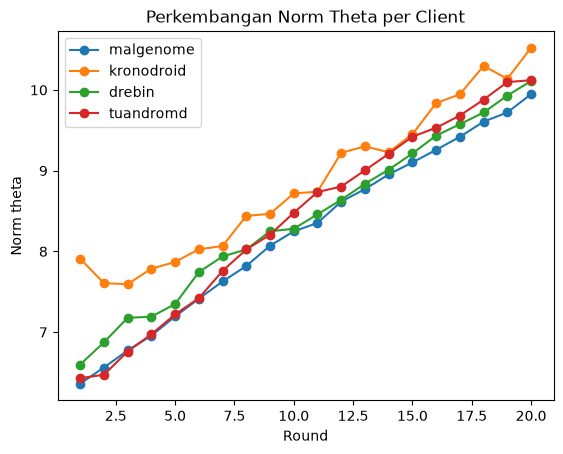

In [10]:
# %% [Cell 6] -- plot norm theta per client per ronde
for cname in df_theta["client"].unique():
    sub = df_theta[df_theta["client"] == cname]
    plt.plot(sub["round"], sub["norm"], marker="o", label=cname)

plt.xlabel("Round")
plt.ylabel("Norm theta")
plt.title("Perkembangan Norm Theta per Client")
plt.legend()
plt.show()

In [11]:
# %%
import pandas as pd

df_test = pd.DataFrame(history["test_per_client"]).T
df_test.index.name = "dataset"
df_test = df_test[["accuracy", "precision", "recall", "f1"]].round(4)
print(df_test)

            accuracy  precision  recall      f1
dataset                                        
drebin        0.9654     0.9199  0.9928  0.9550
kronodroid    0.9213     0.9966  0.8542  0.9199
malgenome     0.9842     0.9787  0.9735  0.9761
tuandromd     0.9985     0.9981  1.0000  0.9991
